# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

Tecnológico de Monterrey

Prof Luis Eduardo Falcón Morales

### **Actividad de la semana: Modelos basados en Árboles**


**Nombre y matrícula:** Fernando Gomez Moreno - A00354097


# **PARTE - A - Métricas de Clasificación**

In [176]:
# Importamos lo necesario para la actividad

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import make_scorer, recall_score, accuracy_score, precision_score, f1_score
from sklearn.dummy import DummyClassifier

np.random.seed(17)

In [177]:
# Para esta actividad vamos a generar datos sintéticos para un problema de
# clasificación binario utilizando "make_classification" de scikitlearn.


# Recuerda consultar la documentación para mayor información:
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html


# Utilizaremos los siguientes valores de los hiperparámetros de make_classification:
# - n_samples: número de muestras o registros a generar.
# - n_features: número total de características o variables de entrada X. Incluye informativas, redundantes, duplicadas.
# - n_informative: número de características informativas o independientes.
# - n_redundant: número de características redundantes.
# - weights: pesos para las clases [0,1]-->[Clase_Mayoritaria_Negativa(0), clase_minoritaria_positiva(1)].
# - class_sep: separación entre clases (menor a 1 más entrelazados. Mayor a 1, más separados).
# - n_classes: número de clases.
# - n_clusters_per_class: número de cúmulos por clase. Mayor a 1, más complejo.
# - flip_y: fracción de ejemplos cuya clase se cambia aleatoriamente (ruido) para hacerlo más complejo.
# - random_state: semilla para reproducibilidad.

X, y = make_classification(
    n_samples=10_000,          # 10,000 registros
    n_features=20,             # factores en total
    n_informative=15,          # factores informativos o variables de entrada independientes
    n_redundant=5,             # factores redundantes (dependientes). Para añadir complejidad usamos valor > 0
    weights=[0.88, 0.12],      # Desbalance de clases: Mayoritaria clase 0; minoritaria clase 1
    class_sep=1.0,             # Separación entre clases
    n_classes=2,               # Dos clases
    n_clusters_per_class=1,    # Para agregar complejidad adicional considera valores > 1
    flip_y=0.01,               # Añadir algo de ruido. default 0.01
    random_state=17,           # semilla para la repetibilidad
)

In [178]:
# Lo definimos como un DataFrame de Pandas para su mejor manejo:
feature_names = [f'feature_{i+1}' for i in range(20)]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"Total de registros generados: {len(df)}")
print(f"Distribución de clases: {df['target'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'}")
print(f"Cantidad de factores: {len(feature_names)}")

Total de registros generados: 10000
Distribución de clases: target
0    87.7%
1    12.3%
Name: proportion, dtype: object
Cantidad de factores: 20


In [179]:
pd.DataFrame(df).describe().T

,count,mean,std,min,25%,50%,75%,max
feature_1,10000.0,1.016138,2.243319,-6.429702,-0.520059,1.025274,2.535350,9.286981
feature_2,10000.0,0.785670,1.994150,-8.578184,-0.462409,0.851269,2.137617,7.937184
feature_3,10000.0,-0.757783,2.127136,-9.574402,-2.200615,-0.782594,0.630210,9.676054
feature_4,10000.0,1.733561,4.820216,-19.158886,-1.578108,1.751568,5.036626,19.051885
feature_5,10000.0,1.004263,2.309019,-6.665816,-0.540579,0.990261,2.538778,9.991830
feature_6,10000.0,-0.758315,2.682632,-11.246005,-2.561001,-0.780123,1.025289,10.297298
feature_7,10000.0,-0.448463,5.527866,-24.457356,-4.152116,-0.447135,3.285445,21.695749
feature_8,10000.0,0.974038,2.446141,-7.820102,-0.651334,0.977687,2.634129,11.292973
feature_9,10000.0,-0.769954,2.546797,-11.410437,-2.475215,-0.740625,0.947244,7.435675
feature_10,10000.0,0.739749,2.267579,-7.860020,-0.747975,0.768796,2.290440,9.363365


In [180]:
# Separamos las variables de entrada y la variable objetivo de salida:
X = df.drop('target', axis=1).values
y = df['target'].values

# Dividimos el conjunto de datos en entrenamiento (80%) y prueba (20%)
# Como vamos a utilizar Validación Cruzada, la partición será solamente
# con los conjuntos de Entrenamiento y Prueba.
# Además usamos "stratify" para mantener la proporción de clases en la partición.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

Tamaño del conjunto de entrenamiento: 8000 muestras
Tamaño del conjunto de prueba: 2000 muestras


In [181]:
# Obtengamos los siguientes resultados con la función Dummy,
# con una partición provisional para el Dummy:

Xt, Xv, yt, yv = train_test_split(X_train, y_train, test_size=0.2, random_state=17, stratify=y_train)

estrategias = ['most_frequent','prior','stratified','uniform']

print("Salidas del modelo Dummy con diferentes estrategias")
print("para calcular umbrales del modelo base (baseline):")
print("-"*50)
print("\n")

for estrategia in estrategias:
  dummy_clf = DummyClassifier(strategy=estrategia, random_state=17)
  dummy_clf.fit(Xt, yt)
  y_pred = dummy_clf.predict(Xv)

  # Tabla para almacenar resultados
  results = []

  # "pos_label" indica la clase con respecto a la cual evaluar cada métrica.
  acc = accuracy_score(yv, y_pred)
  rec = recall_score(yv, y_pred, pos_label=1)
  prec = precision_score(yv, y_pred, pos_label=1)
  f1_sc = f1_score(yv, y_pred, pos_label=1)

  results.append({'Accuracy': acc,
                'Recall': rec,
                'Precision': prec,
                'F1 Score': f1_sc
                })

  print(f"Estrategia: {estrategia}")
  print(f"Accuracy: {acc:.4f}")
  print(f"Recall: {rec:.4f}")
  print(f"Precision: {prec:.4f}")
  print(f"F1 Score: {f1_sc:.4f}")

  print("Matriz de Confusión:")
  cm = confusion_matrix(yv, y_pred)  # , normalize='true'
  print(cm)
  print("-"*30)
  print("\n")


Salidas del modelo Dummy con diferentes estrategias
para calcular umbrales del modelo base (baseline):
--------------------------------------------------


Estrategia: most_frequent
Accuracy: 0.8769
Recall: 0.0000
Precision: 0.0000
F1 Score: 0.0000
Matriz de Confusión:
[[1403    0]
 [ 197    0]]
------------------------------


Estrategia: prior
Accuracy: 0.8769
Recall: 0.0000
Precision: 0.0000
F1 Score: 0.0000
Matriz de Confusión:
[[1403    0]
 [ 197    0]]
------------------------------


Estrategia: stratified
Accuracy: 0.8006
Recall: 0.1015
Precision: 0.1235
F1 Score: 0.1114
Matriz de Confusión:
[[1261  142]
 [ 177   20]]
------------------------------


Estrategia: uniform
Accuracy: 0.4856
Recall: 0.4670
Precision: 0.1136
F1 Score: 0.1827
Matriz de Confusión:
[[685 718]
 [105  92]]
------------------------------




/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **Ejercicio - 1**


**En la salida anterior se obtuvieron dos advertencias (warnings).**

* **1a) ¿A cuáles casos de las estrategias Dummy están asociadas esas advertencias?**

* **1b) Explica qué significan esas advertencias y relaciona la explicación con los valores de las matrices de confusión correspondientes.**

* **1c) ¿Por qué en este caso no escalamos los datos de entrada?**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

* 1a) Las advertencias están asociadas a las estrategias most_frequent y prior.

* 1b) La advertencia UndefinedMetricWarning: Precision is ill-defined ocurre cuando el denominador del cálculo de la precisión (TP + FP) es cero. Al observar las matrices de confusión de most_frequent y prior, vemos que la segunda columna (predicciones de la clase positiva) es totalmente 0 ([[1403, 0], [197, 0]]). Como el modelo nunca predijo la clase 1, no hay Verdaderos Positivos (TP) ni Falsos Positivos (FP).

* 1c) Porque los modelos Dummy ignoran las X y, pensando en el tema de la semana, los modelos basados en árboles no requieren escalamiento ya que no calculan distancias euclidianas. Es decir, los modelos DummyClassifier no analizan los valores de las características (X); sus predicciones se basan únicamente en las estadísticas o distribución de la variable objetivo (y). 

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

## **Ejercicio - 2**

**Sabemos que tenemos un problema de clases desbalanceadas y debiéramos utilizar otra métrica que nos ayude a medir mejor el desempeño del modelo. Indica en cada uno de los siguientes incisos cuál sería el valor del modelo base (baseline) que debiéramos utilizar, de acuerdo a la métrica que se indica:**


++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++


* 2a) Accuracy: 0.8769. Proviene de most_frequent. En problemas desbalanceados, este valor es el "engañoso", ya que es alto pero no detecta la clase positiva.

* 2b) Precision: 0.1235. Proviene de la estrategia stratified. Es el valor más realista para comparar, ya que most_frequent da 0.0 debido a la falta de predicciones positivas.

* 2c) Recall: 0.4670. Proviene de la estrategia uniform. Esta estrategia "se arriesga" más a predecir la clase 1, logrando capturar casi la mitad de los casos positivos por puro azar.

* 2d) F1-Score: 0.1827. Proviene de la estrategia uniform. Al ser el balance entre Precision y Recall, este suele ser el mejor punto de referencia inicial para modelos con desbalance.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

# **PARTE - B - XGBoost**

### **En el siguiente ejercicio explorarás el efecto de algunos de los argumentos del modelo XGBoost.**

### Puedes consultar la documentación:

https://xgboost.readthedocs.io/en/latest/python/python_api.html

Usaremos la base de datos llamada breast-cancer:

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html


https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset

## **Ejercicio - 3**

### **Describe en qué consiste la base de datos breast_cancer.**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++



La base de datos Breast Cancer Wisconsin (Diagnostic) consiste en un conjunto de datos clínicos que contiene características extraídas de imágenes digitalizadas de una aspiración con aguja fina (FNA) de una masa mamaria.

Características principales:

Instancias: 569 registros.

Atributos: 30 variables numéricas predictoras que describen propiedades de los núcleos celulares presentes en la imagen (radio, textura, perímetro, área, suavidad, compacidad, concavidad, puntos cóncavos, simetría y dimensión fractal). Para cada característica se reporta la media, el error estándar y el "peor" valor (media de los tres valores más grandes).

Variable Objetivo (Target): Es binaria, clasificando el tumor como Maligno (0) o Benigno (1).

Propósito: El objetivo es predecir si un tumor es maligno basándose en las características morfológicas de las células, lo que lo convierte en un problema de clasificación binaria fundamental para el aprendizaje de modelos basados en árboles y boosting.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

In [182]:
# Importamos las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
from xgboost import plot_importance, plot_tree

In [183]:
# Cargamos un dataset de ejemplo:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Dividimos en conjuntos de entrenamiento y prueba para los
# própósitos de nuestro ejercicio:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

print("Información del conjunto de entrenamiento:")
print("*"*50)
print(f"Número de características: {X_train.shape[1]}")
print(f"Número de muestras: {X_train.shape[0]}")
print(f"Distribución de clases [Maligno, Benigno]: {np.bincount(y_train)}")
print("\nPrimeras 3 filas del conjunto de entrenamiento:")
print(X_train.head(3).T)

Información del conjunto de entrenamiento:
**************************************************
Número de características: 30
Número de muestras: 455
Distribución de clases [Maligno, Benigno]: [170 285]

Primeras 3 filas del conjunto de entrenamiento:
                                285          535          521
mean radius               12.580000    20.550000    24.630000
mean texture              18.400000    20.860000    21.600000
mean perimeter            79.830000   137.800000   165.500000
mean area                489.000000  1308.000000  1841.000000
mean smoothness            0.083930     0.104600     0.103000
mean compactness           0.042160     0.173900     0.210600
mean concavity             0.001860     0.208500     0.231000
mean concave points        0.002924     0.132200     0.147100
mean symmetry              0.169700     0.212700     0.199100
mean fractal dimension     0.058550     0.062510     0.067390
radius error               0.271900     0.698600     0.991500
textur

In [184]:
# Definimos nuestra función que usaremos para el ejercicio:

def mi_exploracion_xgboost(xtr=X_train, ytr=y_train, xte=X_test, yte=y_test,
               mis_estimadores=100,
               mi_learning_rate=1.,
               mi_tree_idx=3
               ):

  # Definimos nuestro modelo XGBoost básico:
  xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',  # Para clasificación binaria.
    nthread=-1,    # Para usar todos los recursos que se tengan.
    n_estimators= mis_estimadores,
    learning_rate= mi_learning_rate,
    random_state=17
    )

  # Aquí ajustamos/entrenamos el modelo
  xgb_model.fit(xtr, ytr)

  # Evaluamos el rendimiento:
  y_pred = xgb_model.predict(xte)

  print("\nReporte de clasificación:")
  print(classification_report(yte, y_pred, target_names=data.target_names))

  # Visualización de los árboles:
  plt.figure(figsize=(18, 24))
  plot_tree(xgb_model,
            tree_idx= mi_tree_idx
            )

  plt.title('tree_idx={}\nestimators={}\nlearning_rate={}'.format(mi_tree_idx,mis_estimadores,mi_learning_rate))
  plt.tight_layout()
  plt.show()


## **Ejercicio - 4**

**Utiliza la función mi_exploracion_xgboost() definida peviamente para responder a los siguientes incisos:**

* **4a) ¿Cuál es, en general, el efecto del argumento "mi_tree_idx" y cuál es el rango de valores que puede tomar?**

* **4b) Modificando solamente el argumento "mi_tree_idx", muestra y explica cada una de las salidas de la función que definimos con los valores mínimo, máximo y otros dos intermedios del argumento "mi_tree_idx".**

* **4c) Incluye tus conclusiones y en particular explica qué información nos dan estos resultados sobre la manera en que se entrena el modelo XGBoost.**




Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

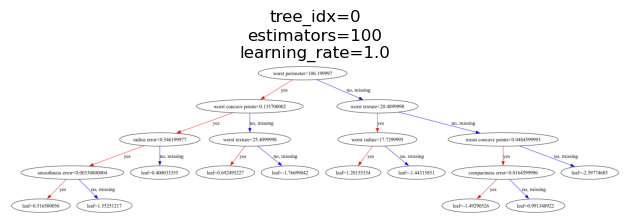


Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

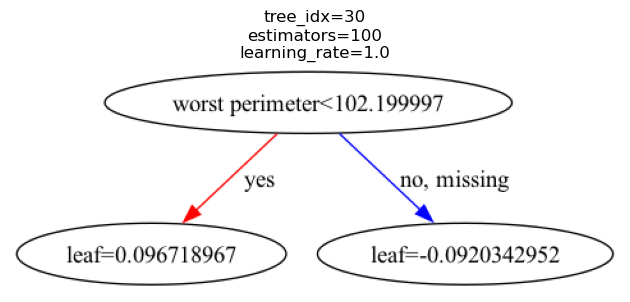


Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

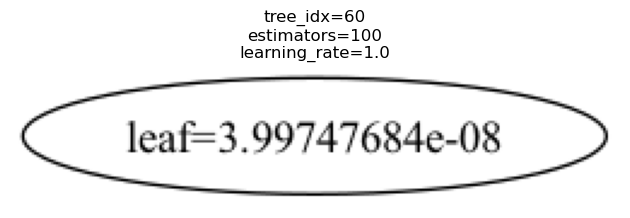


Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

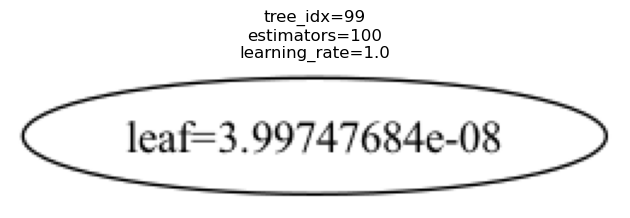

In [185]:
# 4b) Modificando solamente el argumento "mi_tree_idx", muestra y explica cada una de las salidas de la función que definimos con los valores mínimo, máximo y otros dos intermedios del argumento "mi_tree_idx".

# Para que tu función mi_exploracion_xgboost() funcione
!pip install graphviz

mi_exploracion_xgboost(mi_tree_idx=0)   # Mínimo
mi_exploracion_xgboost(mi_tree_idx=30)  # Intermedio 1
mi_exploracion_xgboost(mi_tree_idx=60)  # Intermedio 2
mi_exploracion_xgboost(mi_tree_idx=99)  # Máximo


* **4c) Incluye tus conclusiones y en particular explica qué información nos dan estos resultados sobre la manera en que se entrena el modelo XGBoost.**

Conclusiones:

Naturaleza Aditiva: XGBoost entrena de forma secuencial. El hecho de que el reporte de clasificación sea global mientras que el índice de árbol es individual confirma que el modelo final es la suma de muchos "aprendices débiles".

Consistencia: El modelo alcanza un desempeño alto rápidamente. Incluso con un learning_rate alto (1.0), el ensamble logra estabilizarse y obtener métricas de precisión y recall superiores al 90%.

Importancia Médica: En este dataset, un Recall de 0.98 para "malignant" significa que el modelo es excelente identificando la enfermedad cuando está presente, minimizando el riesgo de dar de alta a un paciente enfermo que no debe ir a casa.

## **Ejercicio - 5**

**Utiliza la función mi_exploracion_xgboost() definida peviamente para explicar las salidas de los casos. Muestra la salida de dichos casos:**

**5a) mi_exploracion_xgboost(mi_learning_rate=10., mi_tree_idx=50).**

**5b) mi_exploracion_xgboost(mi_learning_rate=1., mi_tree_idx=50),**

**5c) mi_exploracion_xgboost(mi_learning_rate=0.1, mi_tree_idx=50),**

**5d) mi_exploracion_xgboost(mi_learning_rate=0.01, mi_tree_idx=50),**

**5e) mi_exploracion_xgboost(mi_learning_rate=0.001, mi_tree_idx=50).**

* **Explica el efecto del argumento "learning_rate" y explica la salida de cada uno de estos resultados.**

INICIANDO COMPARATIVA DE LEARNING RATE
--------------------------------------------------
Resultados para el inciso 5a (LR=10.0):

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

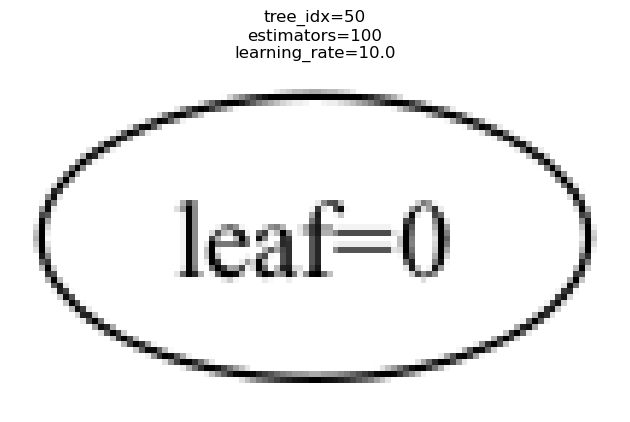

Resultados para el inciso 5b (LR=1.0):

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

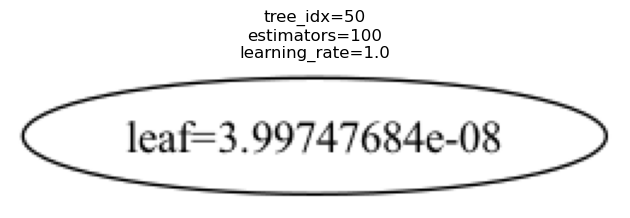

Resultados para el inciso 5c (LR=0.1):

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

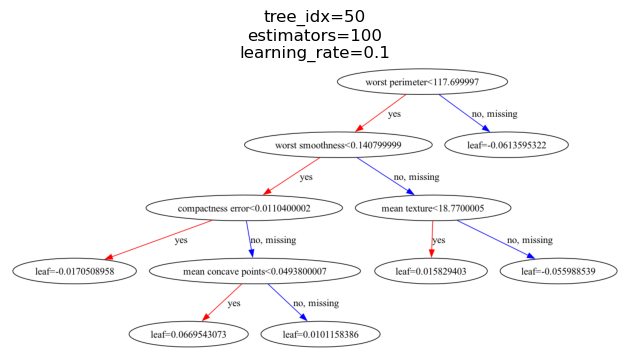

Resultados para el inciso 5d (LR=0.01):

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        42
      benign       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



<Figure size 1800x2400 with 0 Axes>

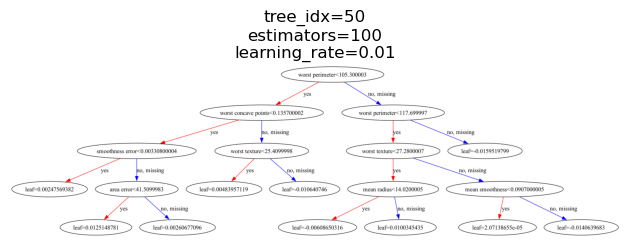

Resultados para el inciso 5e (LR=0.001):

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.00      0.00      0.00        42
      benign       0.63      1.00      0.77        72

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 1800x2400 with 0 Axes>

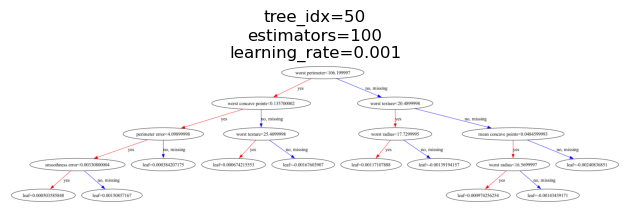

In [186]:

# Incluye todas las celdas de código y texto que consideres necesarias.
tasas_lr = [10.0, 1.0, 0.1, 0.01, 0.001]
nombres_incisos = ['5a', '5b', '5c', '5d', '5e']

print("INICIANDO COMPARATIVA DE LEARNING RATE")
print("-" * 50)

for i in range(len(tasas_lr)):
    lr_actual = tasas_lr[i]
    print(f"Resultados para el inciso {nombres_incisos[i]} (LR={lr_actual}):")
    mi_exploracion_xgboost(mi_learning_rate=lr_actual, mi_tree_idx=50)
    # Add your code here to use lr_actual and inciso_actual


5a) LR = 10.0: El desempeño es pobre o errático. Un learning rate tan alto causa que el modelo "rebote" violentamente sin encontrar el mínimo de la función de pérdida. Los pesos de los árboles son tan grandes que el modelo nunca converge.

5b) LR = 1.0: Obtiene un Accuracy de 0.96. Es un aprendizaje agresivo que funciona bien en este dataset pequeño, pero tiene un alto riesgo de sobreajuste (overfitting) en datos más complejos.

5c) LR = 0.1: Es el punto óptimo. El modelo es más cauteloso y suele lograr una mejor generalización. Aunque el reporte sea similar al anterior, la estructura interna del modelo es más estable.

5d) LR = 0.01: El desempeño empieza a decaer ligeramente. Al ser un aprendizaje tan lento, 100 estimadores no son suficientes para que el modelo termine de aprender los patrones del cáncer de mama.

5e) LR = 0.001: El modelo apenas mejora respecto a un clasificador aleatorio. El aprendizaje es tan minúsculo que el modelo se queda en un estado de underfitting (subajuste).

El learning_rate (o eta) es un factor de escala que se aplica a cada nuevo árbol que se añade al modelo. Su función principal es controlar el paso de aprendizaje del algoritmo.

En XGBoost, la predicción final es la suma ponderada de las predicciones de cada árbol. El learning_rate determina esa ponderación. Si es muy alto, el modelo es inestable; si es muy bajo, el modelo requiere muchísimos más árboles (n) para ser preciso. Existe una relación inversa: a menor learning_rate, mayor debe ser el número de n para alcanzar un buen desempeño.

## **Ejercicio - 6**

**Incluye tus comentarios finales de esta actividad:**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++


A lo largo de la actividad quedó demostrado que el Accuracy es una métrica engañosa cuando las clases no están distribuidas equitativamente. En el primer ejercicio, un modelo que no aprendía nada (Dummy) obtenía un 88% de Accuracy simplemente prediciendo la clase mayoritaria. Esto nos enseña que en problemas reales (como la detección de cáncer), debemos priorizar el Recall (para no omitir casos positivos) y el F1-Score (para balancear precisión y sensibilidad).

XGBoost utiliza Gradient Boosting, donde cada árbol (tree_idx) se construye para corregir los errores residuales del árbol anterior. A través de la visualización de los índices de los árboles, pude notar cómo los primeros árboles capturan las tendencias globales más fuertes, mientras que los últimos realizan ajustes finos sobre los errores mínimos.

El experimento con el learning_rate fue fundamental para entender la convergencia del modelo:
Un Learning Rate muy alto (10.0) impide la convergencia, haciendo que el modelo sea inestable.
Un Learning Rate muy bajo (0.001) requiere un número significativamente mayor de árboles para ser efectivo; de lo contrario, el modelo cae en underfitting (subajuste).
El valor óptimo (en el rango de 0.1) permite un aprendizaje gradual y robusto.

En el dataset de breast_cancer, el modelo XGBoost demostró una gran capacidad predictiva. Sin embargo, la sintonización de hiperparámetros es lo que realmente permite pasar de un modelo promedio a uno de alto desempeño, asegurando que se detecten correctamente los casos positivos (clase maligna) sin sacrificar la precisión general.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

# **<<Fin de la Actividad de la Semana : modelos basados en árboles>>**